In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data + constants
DATA_PATH = "career_dataset_final.csv"
LABEL_COL = "job_role"
DOMAIN_COL = "career_domain"
SEED = 42

df = pd.read_csv(DATA_PATH)

# Output folder for saved files
OUT_DIR = Path("artifacts_layer1_2")
OUT_DIR.mkdir(exist_ok=True)
print("Dataset shape:", df.shape)
print("Total columns:", len(df.columns))

Dataset shape: (30000, 88)
Total columns: 88


In [ ]:
# LAYER 1: Data Preparation & EDA

In [4]:
df.head()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,"Cloud, DevOps & Platform Engineering",71.42,80.80,8.16,5.81,5.82,5.77,4.27,5.59,2.96,...,2.14,0,0,0,0,2.54,0,2.59,2.44,Platform Engineer
1,Software Engineering,48.74,75.35,9.14,6.82,3.33,3.38,5.62,6.73,4.71,...,2.16,0,0,0,0,3.29,0,2.36,2.81,Application Support Engineer
2,Cybersecurity,75.15,75.85,8.48,3.73,5.90,4.69,1.68,2.89,4.38,...,5.24,2,3,0,5,0.61,0,1.91,5.83,GRC Analyst
3,Cybersecurity,58.15,73.91,8.72,6.28,6.53,2.29,1.57,6.86,2.48,...,7.83,13,12,6,0,1.92,0,3.40,3.08,Cybersecurity Engineer
4,Data & Artificial Intelligence,89.58,95.37,9.31,7.66,5.75,2.21,1.46,9.80,3.70,...,4.35,1,1,0,0,2.60,0,2.43,2.90,Data Analyst


In [5]:
df.dtypes

career_domain                         str
math_scores                       float64
cs_fundamentals_scores            float64
cgpa                              float64
cognitive_ability_score           float64
                                   ...   
embedded_c_cpp_skill              float64
microcontroller_projects_count      int64
rtos_experience_score             float64
firmware_debugging_skill          float64
job_role                              str
Length: 88, dtype: object

In [6]:
display(df.dtypes.value_counts().rename("count").to_frame())

,count
int64,50
float64,36
str,2


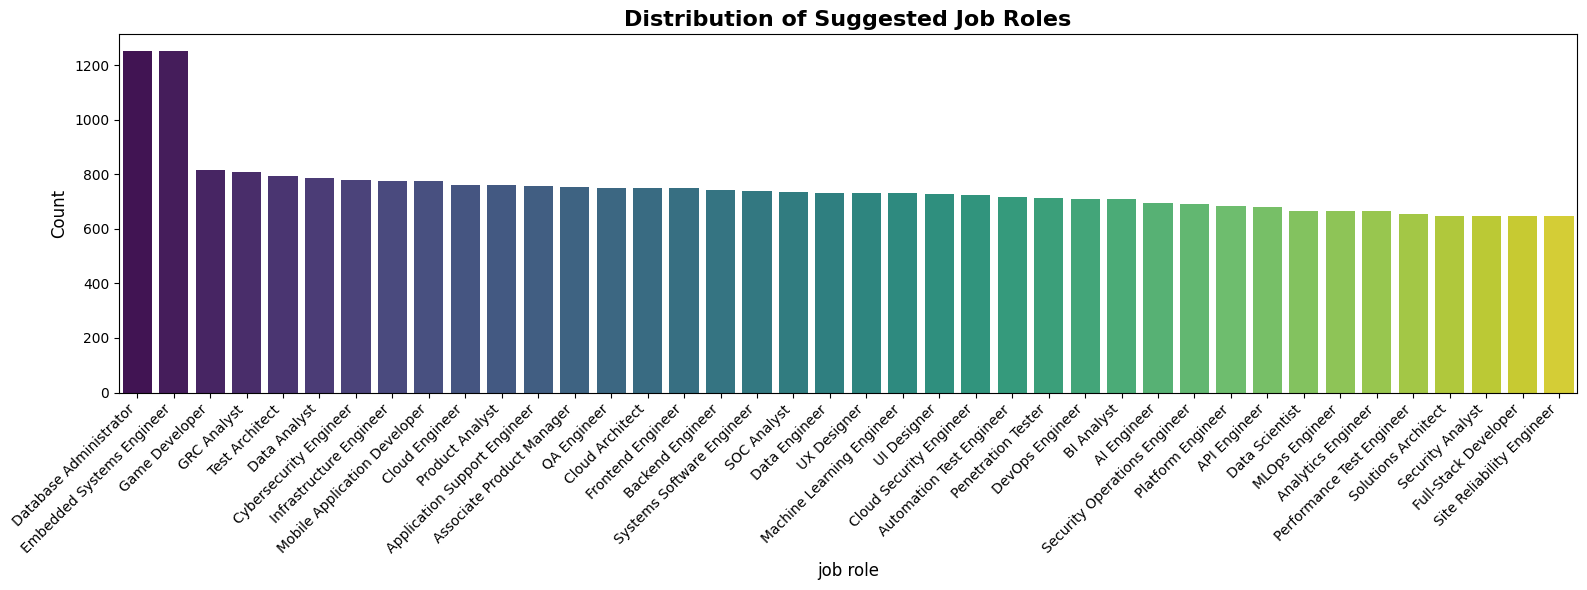

In [7]:
# Job Role Distribution (Full dataset)
plt.figure(figsize=(16, 6))
job_counts = df["job_role"].value_counts()
sns.barplot( x=job_counts.index,y=job_counts.values,hue=job_counts.index,palette="viridis",legend=False)
plt.title("Distribution of Suggested Job Roles", fontsize=16, fontweight="bold")
plt.xlabel("job role", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
df.isnull()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Target columns check
required_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    required_cols.append(DOMAIN_COL)

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Required columns present:", required_cols)

Required columns present: ['job_role', 'career_domain']


In [ ]:
# Missing values check
missing_total = int(df.isna().sum().sum())
print("Total missing cells:", missing_total)

Total missing cells: 0


In [ ]:
# Duplicate rows
dup_rate = float(df.duplicated().mean())
print("Duplicate row rate:", round(dup_rate, 6))

Duplicate row rate: 0.0


In [12]:
# Constant columns (only 1 unique value)
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
print("Constant columns count:", len(constant_cols))
if constant_cols:
    print("Sample constant columns:", constant_cols[:40])

Constant columns count: 0


In [ ]:
# Leakage audit (simple checks)
def tokenize(text: str):
    return re.findall(r"[A-Za-z0-9_+\-]+", str(text).lower())

# Build label token set (words from job roles)
label_values = df[LABEL_COL].astype(str).unique().tolist()
label_tokens = set()
for lv in label_values:
    for t in tokenize(lv):
        if len(t) >= 4:
            label_tokens.add(t)

print("Label token count:", len(label_tokens))

# Suspicious column names (contains label tokens)
suspicious_cols = []
for c in df.columns:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    name_tokens = set(tokenize(c))
    if len(name_tokens & label_tokens) > 0:
        suspicious_cols.append(c)

print("\nSuspicious columns by name (possible leakage):", suspicious_cols[:30])

# Text-like columns check (if any)
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
text_like_cols = []
for c in obj_cols:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    avg_len = df[c].fillna("").astype(str).map(len).mean()
    if avg_len >= 25:
        text_like_cols.append(c)

print("\nText-like columns:", text_like_cols)

# Save leakage report
leakage_report = {
    "label_tokens_count": int(len(label_tokens)),
    "suspicious_feature_names": suspicious_cols,
    "text_like_columns": text_like_cols,
}
(OUT_DIR / "leakage_report.json").write_text(json.dumps(leakage_report, indent=2))
print("\nSaved leakage_report.json")

Label token count: 41

Suspicious columns by name (possible leakage): []

Text-like columns: []

Saved leakage_report.json


In [ ]:
# Target balance summary
role_counts = df[LABEL_COL].astype(str).value_counts()
imbalance_ratio = role_counts.max() / role_counts.min()

print("Number of roles:", role_counts.shape[0])
print("Min count:", int(role_counts.min()))
print("Max count:", int(role_counts.max()))
print("Imbalance ratio (max/min):", round(float(imbalance_ratio), 4))

display(
    pd.DataFrame({
        "count": role_counts.head(40),
        "percent": (role_counts.head(40) / len(df) * 100).round(2)
    })
)

In [ ]:
# Layer-2: Train / Val / Test Split (Stratified)

In [ ]:
# Build X/y safely
y = df[LABEL_COL].astype(str)
drop_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    drop_cols.append(DOMAIN_COL) 

X = df.drop(columns=drop_cols, errors="ignore").copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Dropped:", drop_cols)

X shape: (30000, 86)
y shape: (30000,)
Dropped: ['job_role', 'career_domain']


In [ ]:
# Train/Val/Test Split (stratified)
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

val_relative = 0.10 / (1.0 - 0.20) 
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    random_state=SEED,
    stratify=y_trainval
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", y_train.nunique(), y_val.nunique(), y_test.nunique())

# Save split sizes
split_meta = {
    "seed": SEED,
    "sizes": {"train": len(X_train), "val": len(X_val), "test": len(X_test)},
    "dropped_cols": drop_cols
}
(OUT_DIR / "split_meta.json").write_text(json.dumps(split_meta, indent=2))
print("Saved split_meta.json")

Train: (21000, 86) Val: (3000, 86) Test: (6000, 86)
Classes: 40 40 40
Saved split_meta.json


In [ ]:
# LAYER 3: Feature Engineering & Selection

In [18]:
# Simple feature engineering (safe rules)
def add_simple_engineered_features(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()

    # Activity total (only if columns exist)
    activity_cols = [c for c in ["project_count", "github_commits_90d", "hackathons_participated"] if c in X_out.columns]
    if len(activity_cols) >= 2:
        X_out["activity_total"] = X_out[activity_cols].sum(axis=1)

    # Security total (only if columns exist)
    sec_cols = [c for c in ["pentest_tools_known_count", "vuln_assessments_done", "ctf_participation"] if c in X_out.columns]
    if len(sec_cols) >= 2:
        X_out["security_total"] = X_out[sec_cols].sum(axis=1)

    # Skill rating stats (if you have many *_rating columns)
    rating_cols = [c for c in X_out.columns if c.endswith("_rating")]
    if len(rating_cols) >= 5:
        X_out["skill_rating_mean"] = X_out[rating_cols].mean(axis=1)
        X_out["skill_rating_std"] = X_out[rating_cols].std(axis=1)

    return X_out


X_train_fe = add_simple_engineered_features(X_train)
X_val_fe   = add_simple_engineered_features(X_val)
X_test_fe  = add_simple_engineered_features(X_test)

print("Before FE:", X_train.shape, "After FE:", X_train_fe.shape)

Before FE: (21000, 86) After FE: (21000, 88)


In [19]:
# Correlation-based feature selection (train only)
def find_high_corr_drops(X_train_df: pd.DataFrame, threshold: float = 0.85) -> list:
    numeric_cols = [c for c in X_train_df.columns if pd.api.types.is_numeric_dtype(X_train_df[c])]
    X_num = X_train_df[numeric_cols].copy()

    if X_num.shape[1] < 2:
        return []

    corr = X_num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]
    return to_drop


corr_threshold = 0.85
drop_corr_cols = find_high_corr_drops(X_train_fe, threshold=corr_threshold)

print("Correlated drop count:", len(drop_corr_cols))
print("Sample drop cols:", drop_corr_cols[:20])

# Apply same drop list to val/test
X_train_sel = X_train_fe.drop(columns=drop_corr_cols, errors="ignore")
X_val_sel   = X_val_fe.drop(columns=drop_corr_cols, errors="ignore")
X_test_sel  = X_test_fe.drop(columns=drop_corr_cols, errors="ignore")

print("After selection shapes:", X_train_sel.shape, X_val_sel.shape, X_test_sel.shape)

# Save selection artifacts
(OUT_DIR / "dropped_correlated_features.json").write_text(
    json.dumps({"threshold": corr_threshold, "dropped_features": drop_corr_cols}, indent=2)
)
(OUT_DIR / "selected_features.json").write_text(
    json.dumps({"selected_features": X_train_sel.columns.tolist()}, indent=2)
)

print("Saved dropped_correlated_features.json and selected_features.json")

Correlated drop count: 2
Sample drop cols: ['activity_total', 'security_total']
After selection shapes: (21000, 86) (3000, 86) (6000, 86)
Saved dropped_correlated_features.json and selected_features.json


Numeric columns: 88

Top 20 correlated feature pairs [TRAIN]:


,,abs_corr
activity_total,github_commits_90d,0.999671
github_commits_90d,activity_total,0.999671
security_total,vuln_assessments_done,0.971634
vuln_assessments_done,security_total,0.971634
pentest_tools_known_count,security_total,0.907304
security_total,pentest_tools_known_count,0.907304
vuln_assessments_done,pentest_tools_known_count,0.782129
pentest_tools_known_count,vuln_assessments_done,0.782129
activity_total,project_count,0.768186
project_count,activity_total,0.768186


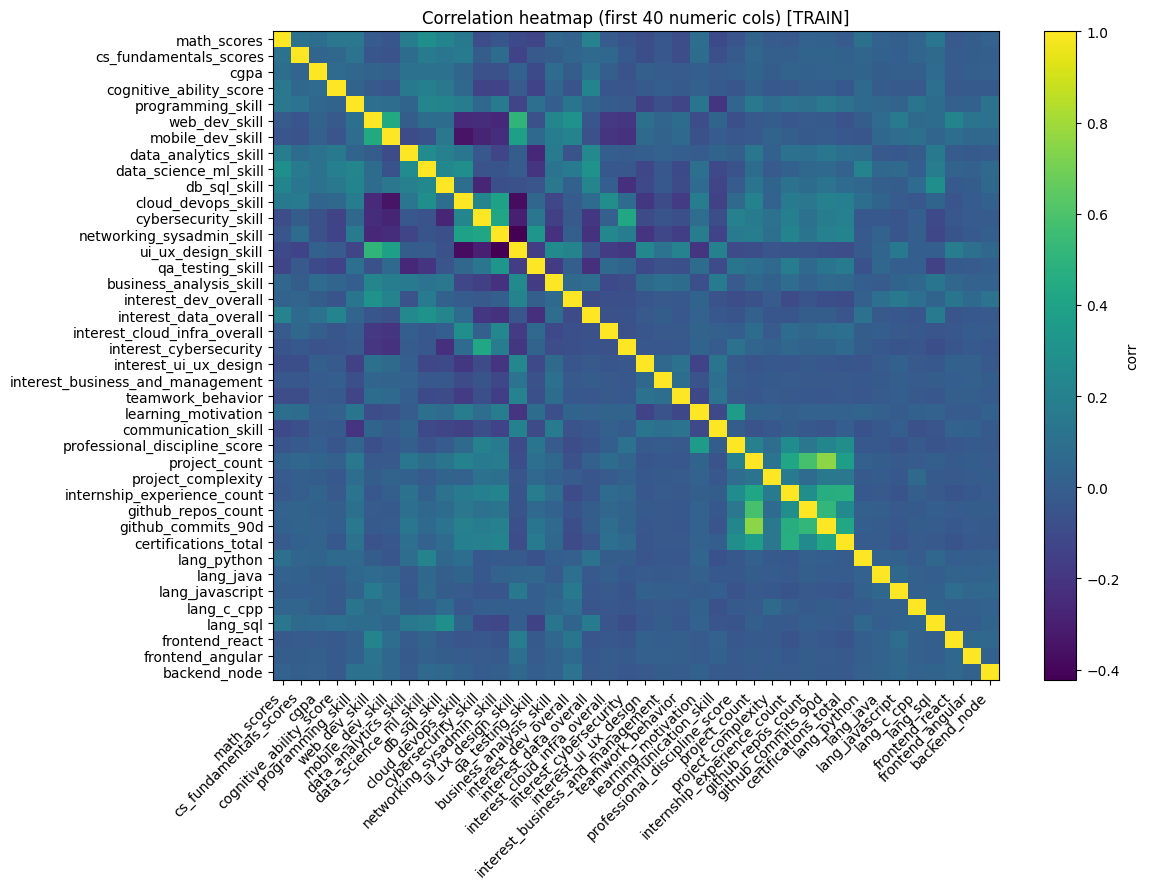

In [20]:
# Correlation report (train only)
num_cols = [c for c in X_train_fe.columns if pd.api.types.is_numeric_dtype(X_train_fe[c])]
print("Numeric columns:", len(num_cols))

if len(num_cols) >= 2:
    # correlation matrix
    corr = X_train_fe[num_cols].corr().abs()
    # Make a writable numpy copy, then zero diagonal
    corr_arr = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_arr, 0)
    # put back into a DataFrame (same labels)
    corr = pd.DataFrame(corr_arr, index=corr.index, columns=corr.columns)
    # top correlated pairs
    pairs = corr.unstack().sort_values(ascending=False)
    pairs = pairs[pairs > 0].head(20)
    print("\nTop 20 correlated feature pairs [TRAIN]:")
    display(pairs.to_frame("abs_corr"))

    # Heatmap (limit for readability)
    N = min(40, len(num_cols))
    small_cols = num_cols[:N]
    corr_small = X_train_fe[small_cols].corr()
    plt.figure(figsize=(12, 9))
    plt.imshow(corr_small.values, aspect="auto")
    plt.colorbar(label="corr")
    plt.xticks(range(len(small_cols)), small_cols, rotation=45, ha="right")
    plt.yticks(range(len(small_cols)), small_cols)
    plt.title(f"Correlation heatmap (first {N} numeric cols) [TRAIN]")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation.")

In [ ]:
# Layer 4: Preprocessing (Fit on TRAIN only) + Safety Checks

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import joblib

# Detect numeric vs categorical columns
numeric_cols = [c for c in X_train_sel.columns if pd.api.types.is_numeric_dtype(X_train_sel[c])]
categorical_cols = [c for c in X_train_sel.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Example numeric:", numeric_cols[:10])
print("Example categorical:", categorical_cols[:10])


Numeric columns: 86
Categorical columns: 0
Example numeric: ['math_scores', 'cs_fundamentals_scores', 'cgpa', 'cognitive_ability_score', 'programming_skill', 'web_dev_skill', 'mobile_dev_skill', 'data_analytics_skill', 'data_science_ml_skill', 'db_sql_skill']
Example categorical: []


In [ ]:
# Numeric preprocessing
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine them
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop"
)
print("Preprocessor ready.")
preprocess

Preprocessor ready.


In [ ]:
# Fit on TRAIN only + transform VAL/TEST
X_train_proc = preprocess.fit_transform(X_train_sel)
X_val_proc = preprocess.transform(X_val_sel)
X_test_proc = preprocess.transform(X_test_sel)

print("Processed shapes:")
print("Train:", X_train_proc.shape)
print("Val  :", X_val_proc.shape)
print("Test :", X_test_proc.shape)

Processed shapes:
Train: (21000, 86)
Val  : (3000, 86)
Test : (6000, 86)


In [ ]:
# Safety checks (shapes, NaN/Inf)
def check_same_columns():
    a = list(X_train_sel.columns)
    b = list(X_val_sel.columns)
    c = list(X_test_sel.columns)
    print("Train vs Val columns identical:", a == b)
    print("Train vs Test columns identical:", a == c)

check_same_columns()

def check_matrix_ok(mat, name):
    arr = mat.toarray() if hasattr(mat, "toarray") else np.asarray(mat)
    print(name, "NaNs:", int(np.isnan(arr).sum()), "| Infs:", int(np.isinf(arr).sum()))

check_matrix_ok(X_train_proc, "X_train_proc")
check_matrix_ok(X_val_proc, "X_val_proc")
check_matrix_ok(X_test_proc, "X_test_proc")

Train vs Val columns identical: True
Train vs Test columns identical: True
X_train_proc NaNs: 0 | Infs: 0
X_val_proc NaNs: 0 | Infs: 0
X_test_proc NaNs: 0 | Infs: 0


In [ ]:
# Label encoding (consistent) + saving
label_encoder = LabelEncoder()

# Fit on TRAIN only
y_train_enc = label_encoder.fit_transform(y_train.astype(str))
y_val_enc = label_encoder.transform(y_val.astype(str))
y_test_enc = label_encoder.transform(y_test.astype(str))

print("Number of classes:", len(label_encoder.classes_))
# Save encoder
joblib.dump(label_encoder, OUT_DIR / "label_encoder.joblib")
print("Saved label_encoder.joblib")

Number of classes: 40
Saved label_encoder.joblib


In [ ]:
#  Save artifacts for reproducibility
joblib.dump(preprocess, OUT_DIR / "preprocess.joblib")

final_feature_list = X_train_sel.columns.tolist()
(OUT_DIR / "final_feature_list.json").write_text(
    json.dumps({"final_feature_list": final_feature_list}, indent=2)
)
print("Saved final_feature_list.json")

# Save feature engineering metadata (what was created)
engineered_features = sorted(list(set(X_train_fe.columns) - set(X_train.columns)))

fe_meta = {
    "engineered_features": engineered_features,
    "notes": "Engineered features are created only if required base columns exist.",
}
(OUT_DIR / "feature_engineering_meta.json").write_text(json.dumps(fe_meta, indent=2))
print("Saved feature_engineering_meta.json")

# Save preprocessing output feature names (useful for debugging later)
try:
    feature_names_out = preprocess.get_feature_names_out().tolist()
except Exception:
    feature_names_out = None

(OUT_DIR / "preprocess_feature_names.json").write_text(
    json.dumps({"feature_names_out": feature_names_out}, indent=2)
)
print("Saved preprocess_feature_names.json")

Saved preprocess + feature metadata.


In [ ]:
# LAYER 5: Model Selection & Training

In [28]:
import json
import joblib
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    top_k_accuracy_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [29]:
# Helper function to train + evaluate on VAL
def eval_on_val(model, X_tr, y_tr, X_v, y_v, k=3):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_v)
    acc = accuracy_score(y_v, pred)
    macro_f1 = f1_score(y_v, pred, average="macro")
    macro_prec = precision_score(y_v, pred, average="macro", zero_division=0)
    macro_rec = recall_score(y_v, pred, average="macro", zero_division=0)
    metrics = {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "macro_precision": float(macro_prec),
        "macro_recall": float(macro_rec),
        "log_loss": None,
        f"top{k}": None,
    }

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_v)
        metrics["log_loss"] = float(log_loss(y_v, proba, labels=np.arange(len(label_encoder.classes_))))
        metrics[f"top{k}"] = float(
            top_k_accuracy_score(y_v, proba, k=k, labels=np.arange(len(label_encoder.classes_)))
        )

    return metrics, model

In [30]:
# SVM (RBF) model + results
svm_model = SVC(
    kernel="rbf", 
    probability=True, 
    random_state=SEED
)

svm_metrics, svm_fitted = eval_on_val(
    svm_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3)
print("SVM_RBF VAL results:", svm_metrics)

SVM_RBF VAL results: {'accuracy': 0.7693333333333333, 'macro_f1': 0.7580179692924596, 'macro_precision': 0.7599941598872743, 'macro_recall': 0.7581094422589962, 'log_loss': 0.6262774770409837, 'top3': 0.9713333333333334}


In [31]:
# Random Forest model + results
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

rf_metrics, rf_fitted = eval_on_val(
    rf_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print("RandomForest VAL results:", rf_metrics)

RandomForest VAL results: {'accuracy': 0.779, 'macro_f1': 0.765070585192801, 'macro_precision': 0.7709944522647919, 'macro_recall': 0.7660908885260462, 'log_loss': 1.0870664204816287, 'top3': 0.957}


In [32]:
# Logistic Regression model + results
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_metrics, lr_fitted = eval_on_val(
    lr_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print("LogisticRegression VAL results:", lr_metrics)

LogisticRegression VAL results: {'accuracy': 0.7673333333333333, 'macro_f1': 0.7562093027311176, 'macro_precision': 0.7569155117719928, 'macro_recall': 0.7571145255304351, 'log_loss': 0.6330245308852797, 'top3': 0.9666666666666667}


In [33]:
# XGBoost model + results
xgb_metrics, xgb_fitted = None, None

try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        eval_metric="mlogloss"
    )

    xgb_metrics, xgb_fitted = eval_on_val(
        xgb_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
    )

    print("XGBoost VAL results:", xgb_metrics)

except Exception as e:
    print("XGBoost not available or failed:", e)

XGBoost VAL results: {'accuracy': 0.772, 'macro_f1': 0.7598294726066037, 'macro_precision': 0.7616074927439197, 'macro_recall': 0.7606309313665588, 'log_loss': 0.6629745696460277, 'top3': 0.9673333333333334}


In [34]:
# LightGBM model + results
lgbm_metrics, lgbm_fitted = None, None

try:
    import lightgbm as lgb

    lgbm_model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        force_col_wise=True,
        min_data_in_leaf=20,
        min_gain_to_split=0.0,
        reg_lambda=1.0,
        verbose=-1,
    )

    lgbm_metrics, lgbm_fitted = eval_on_val(
        lgbm_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
    )

    print("LightGBM VAL results:", lgbm_metrics)

except Exception as e:
    print("LightGBM not available or failed:", e)

c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM VAL results: {'accuracy': 0.7733333333333333, 'macro_f1': 0.7605827450914747, 'macro_precision': 0.7621569813512129, 'macro_recall': 0.7617536376232653, 'log_loss': 0.7583960510605022, 'top3': 0.9666666666666667}


In [49]:
# Compare models
results = []
results.append({"model": "svm_rbf", **svm_metrics})
results.append({"model": "random_forest", **rf_metrics})
results.append({"model": "logistic_regression", **lr_metrics})
results.append({"model": "xgboost", **xgb_metrics}) 
results.append({"model": "lightgbm", **lgbm_metrics})

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
preferred_cols = ["model", "accuracy", "macro_f1", "macro_precision", "macro_recall", "log_loss", "top3"]
results_df = results_df[[c for c in preferred_cols if c in results_df.columns]]
display(results_df)
    

,model,accuracy,macro_f1,macro_precision,macro_recall,log_loss,top3
1,random_forest,0.779000,0.765071,0.770994,0.766091,1.087066,0.957000
4,lightgbm,0.773333,0.760583,0.762157,0.761754,0.758396,0.966667
3,xgboost,0.772000,0.759829,0.761607,0.760631,0.662975,0.967333
0,svm_rbf,0.769333,0.758018,0.759994,0.758109,0.626277,0.971333
2,logistic_regression,0.767333,0.756209,0.756916,0.757115,0.633025,0.966667


In [35]:
# Compare on VAL + save best model + val results
val_results = {
    "svm_rbf": svm_metrics,
    "random_forest": rf_metrics,
    "logistic_regression": lr_metrics,
}

trained_models = {
    "svm_rbf": svm_fitted,
    "random_forest": rf_fitted,
    "logistic_regression": lr_fitted,
}

if xgb_metrics is not None:
    val_results["xgboost"] = xgb_metrics
    trained_models["xgboost"] = xgb_fitted

if lgbm_metrics is not None:
    val_results["lightgbm"] = lgbm_metrics
    trained_models["lightgbm"] = lgbm_fitted

# Choose best model by Macro-F1 (you can change to Top-3 if you want)
best_name = max(val_results, key=lambda n: val_results[n]["macro_f1"])
best_model = trained_models[best_name]

print("BEST model on VAL (macro_f1):", best_name, val_results[best_name])

# Save
joblib.dump(best_model, OUT_DIR / "best_model_val.joblib")
(OUT_DIR / "val_results.json").write_text(json.dumps(val_results, indent=2))

print("Saved:", OUT_DIR / "best_model_val.joblib")
print("Saved:", OUT_DIR / "val_results.json")

BEST model on VAL (macro_f1): random_forest {'accuracy': 0.779, 'macro_f1': 0.765070585192801, 'macro_precision': 0.7709944522647919, 'macro_recall': 0.7660908885260462, 'log_loss': 1.0870664204816287, 'top3': 0.957}
Saved: artifacts_layer1_2\best_model_val.joblib
Saved: artifacts_layer1_2\val_results.json


In [ ]:
#  Calibration + OOF stacking (correct class alignment)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def aligned_proba(model, X, n_classes):
    proba = model.predict_proba(X)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    aligned[:, model.classes_] = proba
    return aligned

# Calibration (example: calibrate Logistic Regression for better confidence)
calibrated_lr = CalibratedClassifierCV(
    estimator=LogisticRegression(max_iter=2000,class_weight="balanced"),
    method="sigmoid",
    cv=3
)
cal_lr_metrics, cal_lr_fitted = eval_on_val(
    calibrated_lr, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print("Calibrated LR VAL results:", cal_lr_metrics)

# OOF stacking features builder
def build_oof_stack_features(base_models, X_tr, y_tr, X_v, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    n_classes = len(np.unique(y_tr))

    meta_train_parts = []
    meta_val_parts = []

    for name, base in base_models.items():
        oof = np.zeros((X_tr.shape[0], n_classes), dtype=float)
        val_accum = np.zeros((X_v.shape[0], n_classes), dtype=float)

        for tr_idx, oof_idx in skf.split(np.zeros(len(y_tr)), y_tr):
            m = clone(base)
            m.fit(X_tr[tr_idx], y_tr[tr_idx])

            oof[oof_idx] = aligned_proba(m, X_tr[oof_idx], n_classes)
            val_accum += aligned_proba(m, X_v, n_classes)

        val_mean = val_accum / n_splits

        meta_train_parts.append(oof)
        meta_val_parts.append(val_mean)

    meta_train = np.hstack(meta_train_parts)
    meta_val = np.hstack(meta_val_parts)

    return meta_train, meta_val

print("Calibration + OOF stacking helpers ready.")

Calibrated LR VAL results: {'accuracy': 0.7336666666666667, 'macro_f1': 0.7149937031028852, 'macro_precision': 0.7273550696350639, 'macro_recall': 0.719387294600923, 'log_loss': 0.9579650316981165, 'top3': 0.962}
Calibration + OOF stacking helpers ready.


In [ ]:
# Ensemble model: Stacking (XGB + LGBM + LR) 
base_models = {}
# XGB
if xgb_fitted is not None:
    from xgboost import XGBClassifier
    base_models["xgb"] = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        eval_metric="mlogloss"
    )

# LGBM
if lgbm_fitted is not None:
    import lightgbm as lgb
    base_models["lgbm"] = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        force_col_wise=True,
        min_data_in_leaf=20,
        min_gain_to_split=0.0,
        reg_lambda=1.0,
        verbose=-1,
    )

# LR always available
base_models["lr"] = LogisticRegression(max_iter=2000)
print("Stacking base models:", list(base_models.keys()))

# Build OOF meta-features (train) + meta-features (val)
meta_train, meta_val = build_oof_stack_features(
    base_models,
    X_train_proc,
    y_train_enc,
    X_val_proc,
    n_splits=5,
    seed=SEED
)

# Train meta model
meta_model = LogisticRegression(max_iter=2000)
meta_model.fit(meta_train, y_train_enc)

# Evaluate on val
meta_pred = meta_model.predict(meta_val)
meta_acc = accuracy_score(y_val_enc, meta_pred)
meta_f1 = f1_score(y_val_enc, meta_pred, average="macro")

# Top-3 for stacking (meta_model has predict_proba)
meta_proba = meta_model.predict_proba(meta_val)
meta_top3 = top_k_accuracy_score(
    y_val_enc,
    meta_proba,
    k=3,
    labels=np.arange(len(label_encoder.classes_))
)

stacking_results = {
    "accuracy": float(meta_acc),
    "macro_f1": float(meta_f1),
    "top3": float(meta_top3),
}

print("STACKING (XGB+LGBM+LR) VAL results:", stacking_results)

# Save ensemble
joblib.dump({"base_models": base_models, "meta_model": meta_model}, OUT_DIR / "stacking_ensemble.joblib")
(OUT_DIR / "stacking_val_results.json").write_text(json.dumps(stacking_results, indent=2))
print("Saved stacking_ensemble.joblib and stacking_val_results.json")

Stacking base models: ['xgb', 'lgbm', 'lr']


c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: U

STACKING (XGB+LGBM+LR) VAL results: {'accuracy': 0.783, 'macro_f1': 0.7718343633379069, 'top3': 0.9586666666666667}
Saved stacking_ensemble.joblib and stacking_val_results.json


In [ ]:
# LAYER 6: Model Evaluation & Testing

In [39]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    top_k_accuracy_score,
    confusion_matrix,
    classification_report
)

best_model_path = OUT_DIR / "best_model_val.joblib"
ensemble_path = OUT_DIR / "stacking_ensemble.joblib"

best_model = joblib.load(best_model_path) if best_model_path.exists() else None
ensemble_bundle = joblib.load(ensemble_path) if ensemble_path.exists() else None

print("Best model loaded:", best_model is not None, "|", best_model_path)
print("Ensemble loaded :", ensemble_bundle is not None, "|", ensemble_path)

if best_model is None and ensemble_bundle is None:
    raise ValueError("No models found. Train Layer 3 first.")

primary_is_ensemble = (best_model is None and ensemble_bundle is not None)
print("Primary is ensemble:", primary_is_ensemble)

Best model loaded: True | artifacts_layer1_2\best_model_val.joblib
Ensemble loaded : True | artifacts_layer1_2\stacking_ensemble.joblib
Primary is ensemble: False


In [40]:
# Part B: Helper function to evaluate on TEST
def evaluate_single_model(model, X, y, k=3):
    pred = model.predict(X)
    metrics = {
        "accuracy": float(accuracy_score(y, pred)),
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "macro_precision": float(precision_score(y, pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, pred, average="macro", zero_division=0)),
        "log_loss": None,
        f"top{k}": None,
    }
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        metrics["log_loss"] = float(log_loss(y, proba, labels=np.arange(len(label_encoder.classes_))))
        metrics[f"top{k}"] = float(top_k_accuracy_score(y, proba, k=k, labels=np.arange(len(label_encoder.classes_))))
    return metrics

def aligned_proba(model, X, n_classes):
    proba = model.predict_proba(X)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    aligned[:, model.classes_] = proba
    return aligned

def predict_proba_ensemble(bundle, X_train, y_train, X_test):
    base_models = bundle["base_models"]
    meta_model = bundle["meta_model"]
    n_classes = len(np.unique(y_train))

    meta_parts = []
    for name, base in base_models.items():
        m = base
        m.fit(X_train, y_train)
        meta_parts.append(aligned_proba(m, X_test, n_classes))

    meta_X = np.hstack(meta_parts)
    proba = meta_model.predict_proba(meta_X)
    pred = meta_model.predict(meta_X)
    return proba, pred

def evaluate_ensemble(bundle, X_train, y_train, X_test, y_test, k=3):
    proba, pred = predict_proba_ensemble(bundle, X_train, y_train, X_test)
    metrics = {
        "accuracy": float(accuracy_score(y_test, pred)),
        "macro_f1": float(f1_score(y_test, pred, average="macro")),
        "macro_precision": float(precision_score(y_test, pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_test, pred, average="macro", zero_division=0)),
        "log_loss": float(log_loss(y_test, proba, labels=np.arange(len(label_encoder.classes_)))),
        f"top{k}": float(top_k_accuracy_score(y_test, proba, k=k, labels=np.arange(len(label_encoder.classes_)))),
    }
    return metrics, proba, pred

In [41]:
# Part C: Evaluate BEST model on TEST
test_results = {}
best_pred_test = None
best_proba_test = None

if best_model is not None:
    test_results["best_single_model"] = evaluate_single_model(best_model, X_test_proc, y_test_enc, k=3)
    print("Best single model TEST metrics:", test_results["best_single_model"])
    best_pred_test = best_model.predict(X_test_proc)
    best_proba_test = best_model.predict_proba(X_test_proc) if hasattr(best_model, "predict_proba") else None

ens_pred_test = None
ens_proba_test = None

if ensemble_bundle is not None:
    ens_metrics, ens_proba_test, ens_pred_test = evaluate_ensemble(
        ensemble_bundle, X_train_proc, y_train_enc, X_test_proc, y_test_enc, k=3
    )
    test_results["ensemble_model"] = ens_metrics
    print("Ensemble model TEST metrics:", test_results["ensemble_model"])

(OUT_DIR / "test_results_both_models.json").write_text(json.dumps(test_results, indent=2))
print("Saved test_results_both_models.json")

if ensemble_bundle is not None and best_model is None:
    final_model_type = "ensemble"
elif ensemble_bundle is None and best_model is not None:
    final_model_type = "best_single"
else:
    b = test_results["best_single_model"]["macro_f1"]
    e = test_results["ensemble_model"]["macro_f1"]
    final_model_type = "ensemble" if e >= b else "best_single"

print("FINAL model chosen for Layer 5 outputs:", final_model_type)

Best single model TEST metrics: {'accuracy': 0.78, 'macro_f1': 0.7661549673801372, 'macro_precision': 0.7702172336182909, 'macro_recall': 0.7675744161565905, 'log_loss': 1.085965706656871, 'top3': 0.9606666666666667}


c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble model TEST metrics: {'accuracy': 0.7973333333333333, 'macro_f1': 0.7875593640733319, 'macro_precision': 0.788561489040587, 'macro_recall': 0.7875171343046885, 'log_loss': 0.6026430853609825, 'top3': 0.9663333333333334}
Saved test_results_both_models.json
FINAL model chosen for Layer 5 outputs: ensemble


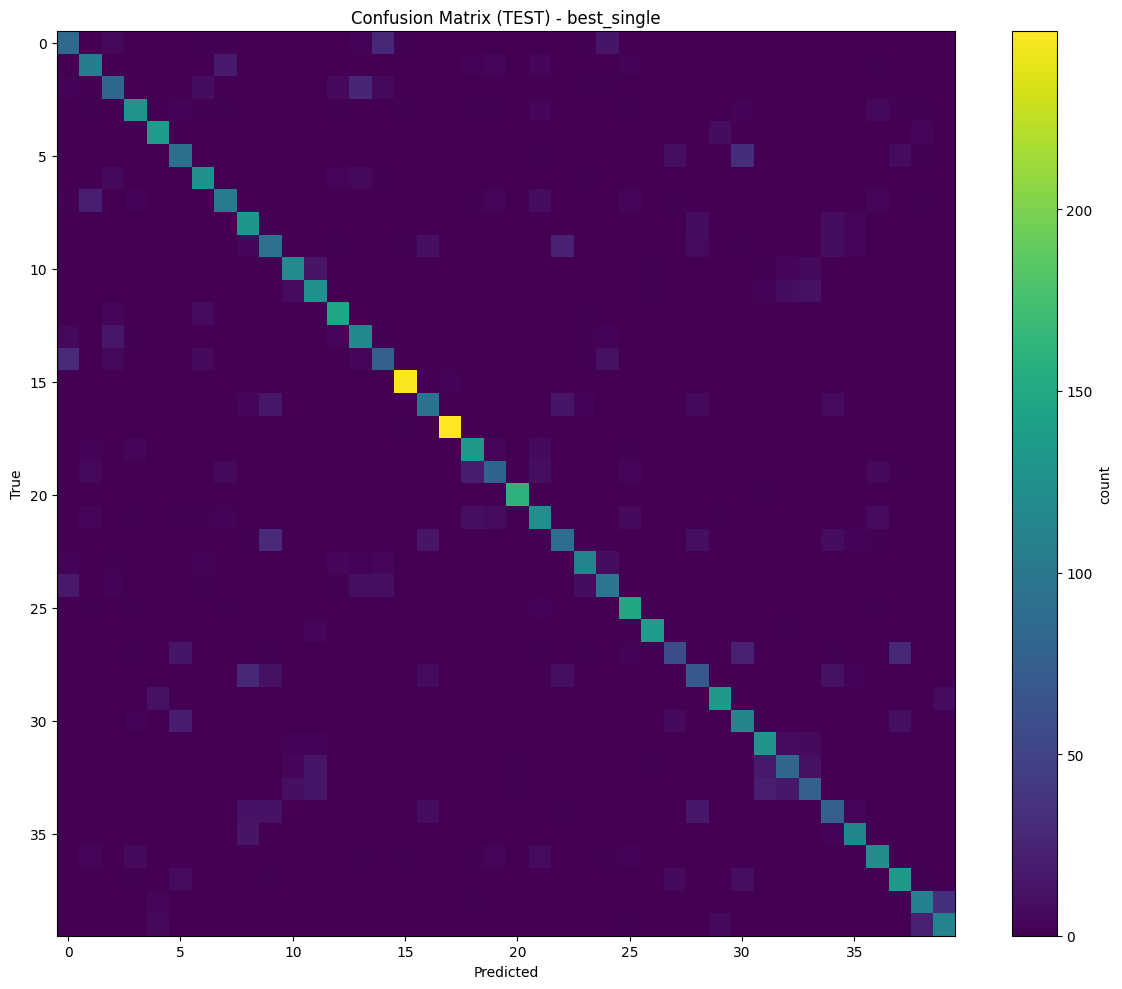

Saved best_single report + confusion matrix files.


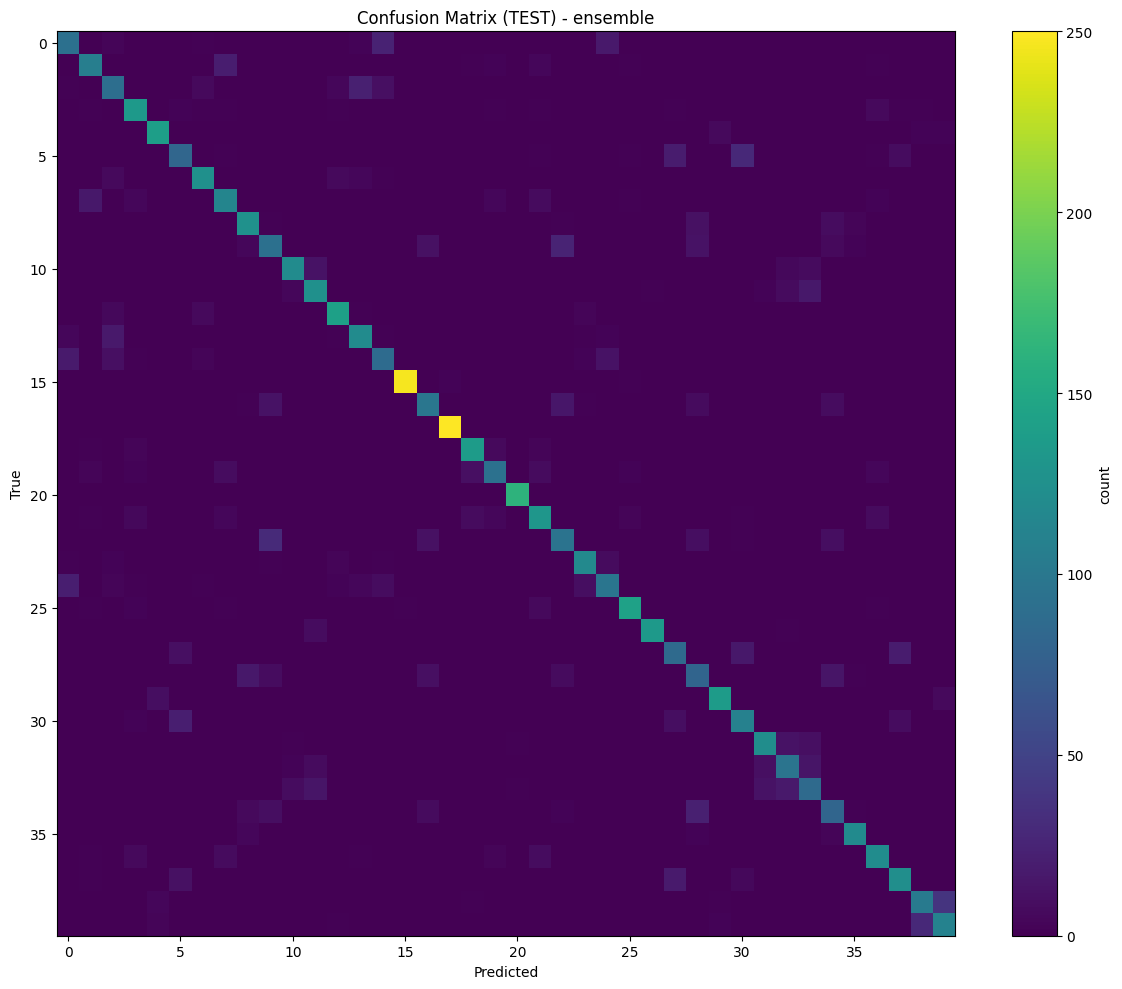

Saved ensemble report + confusion matrix files.


In [42]:
# Part D: Reports + Confusion matrices (for BOTH models)
def save_reports(prefix, y_true, y_pred):
    rpt = classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)
    (OUT_DIR / f"{prefix}_classification_report_test.txt").write_text(rpt)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
    cm_df.to_csv(OUT_DIR / f"{prefix}_confusion_matrix_test.csv", index=True)

    plt.figure(figsize=(12, 10))
    plt.imshow(cm, aspect="auto")
    plt.colorbar(label="count")
    plt.title(f"Confusion Matrix (TEST) - {prefix}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{prefix}_confusion_matrix_test.png", dpi=200)
    plt.show()

    print(f"Saved {prefix} report + confusion matrix files.")

if best_pred_test is not None:
    save_reports("best_single", y_test_enc, best_pred_test)

if ens_pred_test is not None:
    save_reports("ensemble", y_test_enc, ens_pred_test)

In [ ]:
# LAYER 7: Output Layer

In [ ]:
# Part A: Load role->domain mapping (optional)
role_to_domain_path = OUT_DIR / "role_to_domain.json"
role_to_domain = json.loads(role_to_domain_path.read_text()) if role_to_domain_path.exists() else {}

print("role_to_domain loaded:", len(role_to_domain))

role_to_domain loaded: 0


In [44]:
# Part B: Helper: proba -> Top-1/Top-3 recommendations
def topk_from_proba(proba_row, k=3):
    idx = np.argsort(proba_row)[::-1][:k]
    roles = label_encoder.inverse_transform(idx)
    probs = proba_row[idx]
    return [(roles[i], float(probs[i])) for i in range(len(idx))]

def output_df_from_proba(proba, k=3):
    rows = []
    for i in range(proba.shape[0]):
        topk = topk_from_proba(proba[i], k=k)
        top1_role, top1_prob = topk[0]
        rows.append({
            "top1_role": top1_role,
            "top1_prob": round(top1_prob, 6),
            "top1_domain": role_to_domain.get(top1_role, None),
            "top3": topk
        })
    return pd.DataFrame(rows)

def proba_single(model, X):
    if not hasattr(model, "predict_proba"):
        raise ValueError("Single model must support predict_proba for Top-K output.")
    return model.predict_proba(X)

def proba_ensemble(bundle, X_train, y_train, X_test):
    proba, _ = predict_proba_ensemble(bundle, X_train, y_train, X_test)
    return proba

In [45]:
# Part C: Generate outputs (Top-1 + Top-3) on TEST 
if best_model is not None:
    best_proba = proba_single(best_model, X_test_proc)
    best_out = output_df_from_proba(best_proba, k=3)
    display(best_out.head(10))
    best_out.to_csv(OUT_DIR / "topk_outputs_test_best_single.csv", index=False)
    print("Saved topk_outputs_test_best_single.csv")

if ensemble_bundle is not None:
    ens_proba = proba_ensemble(ensemble_bundle, X_train_proc, y_train_enc, X_test_proc)
    ens_out = output_df_from_proba(ens_proba, k=3)
    display(ens_out.head(10))
    ens_out.to_csv(OUT_DIR / "topk_outputs_test_ensemble.csv", index=False)
    print("Saved topk_outputs_test_ensemble.csv")

,top1_role,top1_prob,top1_domain,top3
0,Machine Learning Engineer,0.370000,None,"[(Machine Learning Engineer, 0.37), (AI Engine..."
1,Database Administrator,0.820000,None,"[(Database Administrator, 0.82), (Embedded Sys..."
2,GRC Analyst,0.713333,None,"[(GRC Analyst, 0.7133333333333334), (Applicati..."
3,Security Operations Engineer,0.433333,None,"[(Security Operations Engineer, 0.433333333333..."
4,Cloud Engineer,0.293333,None,"[(Cloud Engineer, 0.29333333333333333), (Infra..."
5,Database Administrator,0.650000,None,"[(Database Administrator, 0.65), (Embedded Sys..."
6,Frontend Engineer,0.523333,None,"[(Frontend Engineer, 0.5233333333333333), (Ful..."
7,Database Administrator,0.300000,None,"[(Database Administrator, 0.3), (Embedded Syst..."
8,Systems Software Engineer,0.430000,None,"[(Systems Software Engineer, 0.43), (Test Arch..."
9,Application Support Engineer,0.246667,None,"[(Application Support Engineer, 0.246666666666..."


Saved topk_outputs_test_best_single.csv


c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,top1_role,top1_prob,top1_domain,top3
0,Machine Learning Engineer,0.774341,None,"[(Machine Learning Engineer, 0.774341011685460..."
1,Database Administrator,0.994860,None,"[(Database Administrator, 0.9948598699918779),..."
2,GRC Analyst,0.994972,None,"[(GRC Analyst, 0.9949715825576998), (Security ..."
3,Security Operations Engineer,0.854732,None,"[(Security Operations Engineer, 0.854732333194..."
4,Cloud Engineer,0.801470,None,"[(Cloud Engineer, 0.8014704633779673), (Infras..."
5,Database Administrator,0.994724,None,"[(Database Administrator, 0.9947244153714735),..."
6,Frontend Engineer,0.883265,None,"[(Frontend Engineer, 0.8832654424941717), (Ful..."
7,Mobile Application Developer,0.410405,None,"[(Mobile Application Developer, 0.410404800712..."
8,Systems Software Engineer,0.964167,None,"[(Systems Software Engineer, 0.964166724552474..."
9,Application Support Engineer,0.967870,None,"[(Application Support Engineer, 0.967869807103..."


Saved topk_outputs_test_ensemble.csv


In [46]:
# Part D: Generate Top-3 outputs for FINAL chosen model
if final_model_type == "ensemble":
    final_proba = proba_ensemble(ensemble_bundle, X_train_proc, y_train_enc, X_test_proc)
    final_out = output_df_from_proba(final_proba, k=3)
    final_out.to_csv(OUT_DIR / "topk_outputs_test_FINAL.csv", index=False)
    print("FINAL model = ENSEMBLE. Saved topk_outputs_test_FINAL.csv")
else:
    final_proba = proba_single(best_model, X_test_proc)
    final_out = output_df_from_proba(final_proba, k=3)
    final_out.to_csv(OUT_DIR / "topk_outputs_test_FINAL.csv", index=False)
    print("FINAL model = BEST SINGLE. Saved topk_outputs_test_FINAL.csv")

display(final_out.head(10))

c:\Users\Manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL model = ENSEMBLE. Saved topk_outputs_test_FINAL.csv


,top1_role,top1_prob,top1_domain,top3
0,Machine Learning Engineer,0.774341,None,"[(Machine Learning Engineer, 0.774341011685460..."
1,Database Administrator,0.994860,None,"[(Database Administrator, 0.9948598699918779),..."
2,GRC Analyst,0.994972,None,"[(GRC Analyst, 0.9949715825576998), (Security ..."
3,Security Operations Engineer,0.854732,None,"[(Security Operations Engineer, 0.854732333194..."
4,Cloud Engineer,0.801470,None,"[(Cloud Engineer, 0.8014704633779673), (Infras..."
5,Database Administrator,0.994724,None,"[(Database Administrator, 0.9947244153714735),..."
6,Frontend Engineer,0.883265,None,"[(Frontend Engineer, 0.8832654424941717), (Ful..."
7,Mobile Application Developer,0.410405,None,"[(Mobile Application Developer, 0.410404800712..."
8,Systems Software Engineer,0.964167,None,"[(Systems Software Engineer, 0.964166724552474..."
9,Application Support Engineer,0.967870,None,"[(Application Support Engineer, 0.967869807103..."
